In [30]:
import os

for folder in os.listdir("/kaggle/input/datasets"):
    print(folder)

for root, dirs, files in os.walk("/kaggle/input/datasets"):
    for file in files:
        print(os.path.join(root, file))

import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/karansridhar/marketing-and-product-performance/marketing_and_product_performance.csv")

df.head()


karansridhar
/kaggle/input/datasets/karansridhar/marketing-and-product-performance/marketing_and_product_performance.csv


,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [31]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/karansridhar/marketing-and-product-performance/marketing_and_product_performance.csv")
df.columns

Index(['Campaign_ID', 'Product_ID', 'Budget', 'Clicks', 'Conversions',
       'Revenue_Generated', 'ROI', 'Customer_ID', 'Subscription_Tier',
       'Subscription_Length', 'Flash_Sale_ID', 'Discount_Level', 'Units_Sold',
       'Bundle_ID', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund',
       'Common_Keywords'],
      dtype='object')

In [32]:
target = 'Revenue_Generated'

In [33]:
# Load
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_csv("/kaggle/input/datasets/karansridhar/marketing-and-product-performance/marketing_and_product_performance.csv")
df = df.dropna()

# Features
X = df.select_dtypes(include=np.number).drop(columns=['Revenue_Generated'])
y = df['Revenue_Generated']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Models
models = {
    "Linear": LinearRegression(),
    "Tree": DecisionTreeRegressor(),
    "KNN": KNeighborsRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    results.append([
        name,
        mean_absolute_error(y_test, pred),
        np.sqrt(mean_squared_error(y_test, pred)),
        r2_score(y_test, pred)
    ])

# Table
table = pd.DataFrame(results, columns=["Model","MAE","RMSE","R2"])
table

,Model,MAE,RMSE,R2
0,Linear,24809.046282,28587.322919,-0.001054
1,Tree,33294.798055,40803.899744,-1.039454
2,KNN,26585.316776,31517.543673,-0.216789


In [34]:
table.to_csv('table_rq1.csv', index=False)

print("Table saved")

Table saved


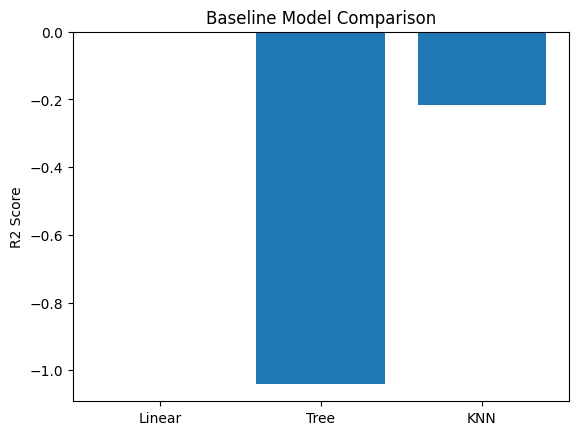

In [35]:
import matplotlib.pyplot as plt
plt.figure() 
plt.bar(table["Model"],table["R2"]) 
plt.title("Baseline Model Comparison") 
plt.ylabel("R2 Score") 
plt.savefig('figure_rq1.pdf')
plt.show()